<a href="https://colab.research.google.com/github/aleakucing/PCVK26_14_IBRA/blob/main/P2_Tugas_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan
mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.

- cv.imread() membaca gambar dengan urutan warna BGR (Blue, Green, Red).  cv2_imshow() menampilkan warna sesuai urutan BGR, jadi warnanya pas (asli).  plt.imshow() mengiranya urutan RGB (Red, Green, Blue). Karena itu, warna biru dan merahnya jadi tertukar

In [305]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [306]:
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

In [307]:
img = cv.imread('/content/drive/MyDrive/PCVK_2026/gambar_bebas.jpg')

1. Tampilan pakai cv2_imshow():


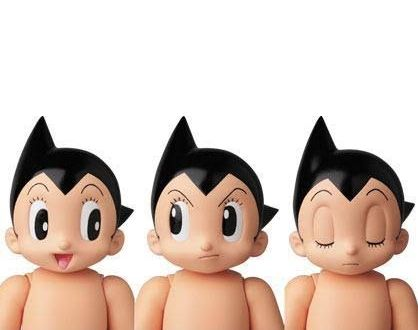

In [308]:
print("1. Tampilan pakai cv2_imshow():")
cv2_imshow(img)

2. Tampilan pakai plt.imshow():


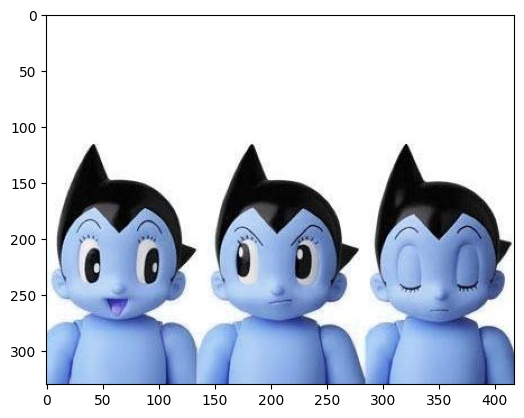

In [309]:
print("2. Tampilan pakai plt.imshow():")
plt.imshow(img)
plt.show()

In [310]:
# 3. Cek nilai pixel
y, x = 230, 215
pixel = img[y, x]

print(f"\nNilai pixel di koordinat ({y}, {x}): {pixel}")
print("Nilai Kanal Blue  :", pixel[0])
print("Nilai Kanal Green :", pixel[1])
print("Nilai Kanal Red   :", pixel[2])


Nilai pixel di koordinat (230, 215): [116 147 210]
Nilai Kanal Blue  : 116
Nilai Kanal Green : 147
Nilai Kanal Red   : 210


2. Apakah tampilannya berbeda?
  - Tidak. Kedua kanvas sama-sama tampil sebagai kotak hitam polos karena seluruh nilai pikselnya adalah nol (0).
  
  Apakah ukuran memorinya berbeda?
  - Ya, berbeda. Ukuran memori kanvas int32 tepat dua kali lipat lebih besar dibandingkan int16.

  - karena Tipe data int16 memakai 16 bit untuk menyimpan setiap piksel, sedangkan int32 memakai 32 bit. Karena ukuran dimensi gambarnya sama (500 \times 500 \times 3), total byte yang dibutuhkan int32 otomatis menjadi 2 kali lebih banyak

In [311]:
# 1. Buat canvas hitam
canvas_int16 = np.zeros((500, 500, 3), dtype=np.int16)
canvas_int32 = np.zeros((500, 500, 3), dtype=np.int32)

In [312]:
# 2. Cetak perbandingan nilai
print("Perbandingan Kanvas int16:")
print("- dtype  :", canvas_int16.dtype)
print("- min()  :", canvas_int16.min())
print("- max()  :", canvas_int16.max())
print("- nbytes :", canvas_int16.nbytes, "bytes")

print("\nPerbandingan Kanvas int32:")
print("- dtype  :", canvas_int32.dtype)
print("- min()  :", canvas_int32.min())
print("- max()  :", canvas_int32.max())
print("- nbytes :", canvas_int32.nbytes, "bytes")

Perbandingan Kanvas int16:
- dtype  : int16
- min()  : 0
- max()  : 0
- nbytes : 1500000 bytes

Perbandingan Kanvas int32:
- dtype  : int32
- min()  : 0
- max()  : 0
- nbytes : 3000000 bytes


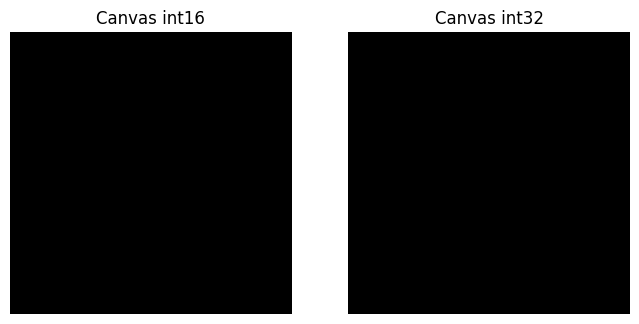

In [313]:
# 3. Menampilkan kedua kanvas
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(canvas_int16)
axes[0].set_title("Canvas int16")
axes[0].axis('off')

axes[1].imshow(canvas_int32)
axes[1].set_title("Canvas int32")
axes[1].axis('off')
plt.show()

3. Kegunaan baris from google.colab.patches import cv2_imshow:
  - Baris ini berfungsi untuk mengimpor fungsi pengganti (patch) dari Google Colab agar gambar OpenCV bisa langsung ditampilkan di dalam sel notebook (sebagai output inline).

  Mengapa cv2.imshow() bawaan OpenCV tidak bisa dipakai di Google Colab?- Fungsi cv2.imshow() asli OpenCV dibuat untuk komputer lokal yang punya antarmuka grafis (GUI) dengan cara memunculkan jendela baru (pop-up window).
  - Google Colab berjalan di server cloud Linux yang tidak memiliki layar/display GUI (headless).
  - Jika kita tetap memanggil cv2.imshow(), Colab akan memunculkan pesan error atau membuat session/kernel Python langsung crash karena tidak ada jendela GUI yang bisa dibuka.

4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.

- Keduanya sama-sama menampilkan warna yang sebenarnya dan tidak ada kanal yang tertukar.skimage.io.imread() secara default sudah membaca citra langsung dalam urutan RGB.  cv.imread() awalnya membaca dalam format BGR, tapi dengan perintah cv.cvtColor(img, cv.COLOR_BGR2RGB), susunannya diubah menjadi RGB.
Karena kedua metode menghasilkan urutan data yang sama (RGB), nilai piksel pada koordinat yang sama bernilai identik.  


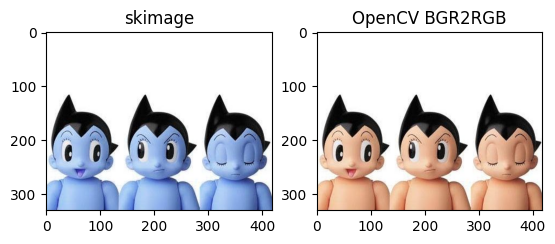

In [314]:
img_skimage = cv.imread('/content/drive/MyDrive/PCVK_2026/gambar_bebas.jpg')
img_cv = cv.imread(path)
img_cv_rgb = cv.cvtColor(img_cv, cv.COLOR_BGR2RGB)

# 1. Tampilkan jejeran pakai subplot biasa
plt.subplot(1, 2, 1)
plt.imshow(img_skimage)
plt.title('skimage')

plt.subplot(1, 2, 2)
plt.imshow(img_cv_rgb)
plt.title('OpenCV BGR2RGB')

plt.show()


In [315]:
# 2. Cek nilai pixel
y, x = 230, 215
p_skimage = img_skimage[y, x]
p_cv_bgr  = img_cv[y, x]
p_cv_rgb  = img_cv_rgb[y, x]

print(f"Nilai pixel di titik ({y}, {x}):")
print("skimage          :", p_skimage)
print("OpenCV mentah    :", p_cv_bgr)
print("OpenCV di-convert:", p_cv_rgb)

Nilai pixel di titik (230, 215):
skimage          : [116 147 210]
OpenCV mentah    : [116 147 210]
OpenCV di-convert: [210 147 116]


5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.

- tidak, nilai img.shape tidak ikut berubah. kalau mengubah ukuran citra memodifikasi data array pixel pada citra sedangkan mengubah ukuran gambar hanya memperbesar kotak kanvas 1 frame tampilan visual layar

**TUGAS PRAKTIKUM - Penerapan**

 1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya

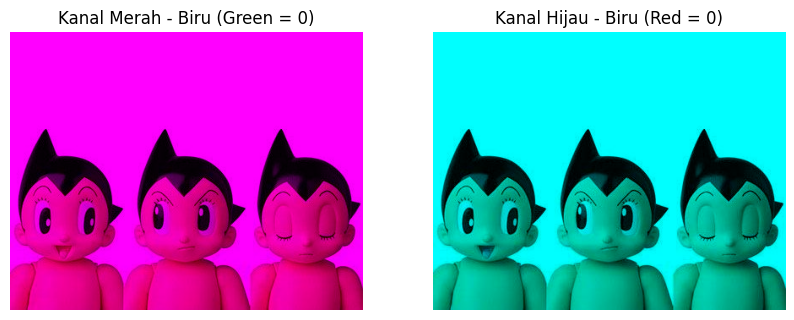

In [316]:
img = cv.imread('/content/drive/MyDrive/PCVK_2026/gambar_bebas.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_rb = img_rgb.copy()
img_gb = img_rgb.copy()

img_rb[:, :, 1] = 0

img_gb[:, :, 0] = 0

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title('Kanal Merah - Biru (Green = 0)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title('Kanal Hijau - Biru (Red = 0)')
plt.axis('off')

plt.show()

3. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan
keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi
label.

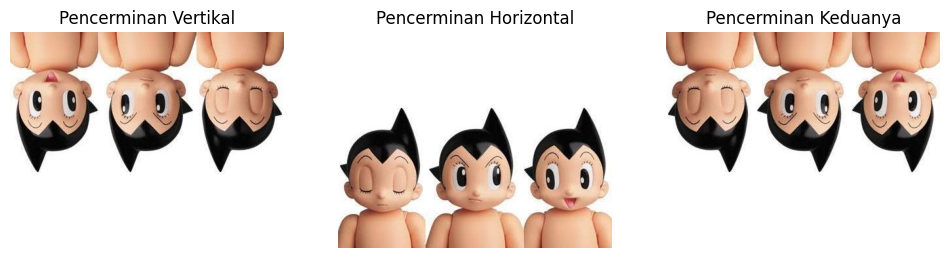

In [317]:
# variabel flip
flip_vertikal   = cv.flip(img_rgb, 0)
flip_horizontal = cv.flip(img_rgb, 1)
flip_keduanya   = cv.flip(img_rgb, -1)

# menampilkan di 3 subplot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(flip_vertikal)
plt.title('Pencerminan Vertikal')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(flip_horizontal)
plt.title('Pencerminan Horizontal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(flip_keduanya)
plt.title('Pencerminan Keduanya')
plt.axis('off')

plt.show()

5. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah /
badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan
teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda
tentukan sendiri.

In [318]:
#1. import
img = cv.imread('/content/drive/MyDrive/PCVK_2026/aktifitas.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_hasil = img_rgb.copy()

In [319]:
#2. menambahkan kotak
cv.rectangle(img_hasil, pt1=(540, 770), pt2=(770, 1070), color=(255, 0, 0), thickness=4)

array([[[118, 173, 212],
        [118, 173, 212],
        [118, 173, 212],
        ...,
        [180, 218, 239],
        [180, 218, 239],
        [182, 219, 238]],

       [[118, 173, 212],
        [118, 173, 212],
        [118, 173, 212],
        ...,
        [181, 219, 240],
        [181, 219, 240],
        [183, 220, 239]],

       [[118, 173, 212],
        [118, 173, 212],
        [118, 173, 212],
        ...,
        [183, 219, 241],
        [184, 221, 240],
        [185, 222, 241]],

       ...,

       [[119, 116,  45],
        [126, 123,  54],
        [130, 127,  60],
        ...,
        [250, 249, 254],
        [250, 249, 254],
        [249, 248, 253]],

       [[167, 164,  93],
        [158, 155,  84],
        [158, 155,  88],
        ...,
        [225, 224, 229],
        [224, 223, 228],
        [222, 221, 226]],

       [[154, 151,  80],
        [135, 132,  61],
        [148, 145,  78],
        ...,
        [163, 162, 167],
        [161, 160, 165],
        [159, 158, 163]]

In [320]:
#3. menambahkan
cv.circle(img_hasil, center=(680, 655), radius=100, color=(0, 255, 0), thickness=4)

array([[[118, 173, 212],
        [118, 173, 212],
        [118, 173, 212],
        ...,
        [180, 218, 239],
        [180, 218, 239],
        [182, 219, 238]],

       [[118, 173, 212],
        [118, 173, 212],
        [118, 173, 212],
        ...,
        [181, 219, 240],
        [181, 219, 240],
        [183, 220, 239]],

       [[118, 173, 212],
        [118, 173, 212],
        [118, 173, 212],
        ...,
        [183, 219, 241],
        [184, 221, 240],
        [185, 222, 241]],

       ...,

       [[119, 116,  45],
        [126, 123,  54],
        [130, 127,  60],
        ...,
        [250, 249, 254],
        [250, 249, 254],
        [249, 248, 253]],

       [[167, 164,  93],
        [158, 155,  84],
        [158, 155,  88],
        ...,
        [225, 224, 229],
        [224, 223, 228],
        [222, 221, 226]],

       [[154, 151,  80],
        [135, 132,  61],
        [148, 145,  78],
        ...,
        [163, 162, 167],
        [161, 160, 165],
        [159, 158, 163]]

In [321]:
# 4. Tambahkan teks nama lengkap
teks = 'Muchammad Ibrahim Al Amin'
font = cv.FONT_HERSHEY_SIMPLEX
posisi = (60, 100)
warna = (255, 255, 0)

cv.putText(img_hasil, text=teks, org=posisi, fontFace=font,
           fontScale=1.5, color=warna, thickness=3)

array([[[118, 173, 212],
        [118, 173, 212],
        [118, 173, 212],
        ...,
        [180, 218, 239],
        [180, 218, 239],
        [182, 219, 238]],

       [[118, 173, 212],
        [118, 173, 212],
        [118, 173, 212],
        ...,
        [181, 219, 240],
        [181, 219, 240],
        [183, 220, 239]],

       [[118, 173, 212],
        [118, 173, 212],
        [118, 173, 212],
        ...,
        [183, 219, 241],
        [184, 221, 240],
        [185, 222, 241]],

       ...,

       [[119, 116,  45],
        [126, 123,  54],
        [130, 127,  60],
        ...,
        [250, 249, 254],
        [250, 249, 254],
        [249, 248, 253]],

       [[167, 164,  93],
        [158, 155,  84],
        [158, 155,  88],
        ...,
        [225, 224, 229],
        [224, 223, 228],
        [222, 221, 226]],

       [[154, 151,  80],
        [135, 132,  61],
        [148, 145,  78],
        ...,
        [163, 162, 167],
        [161, 160, 165],
        [159, 158, 163]]

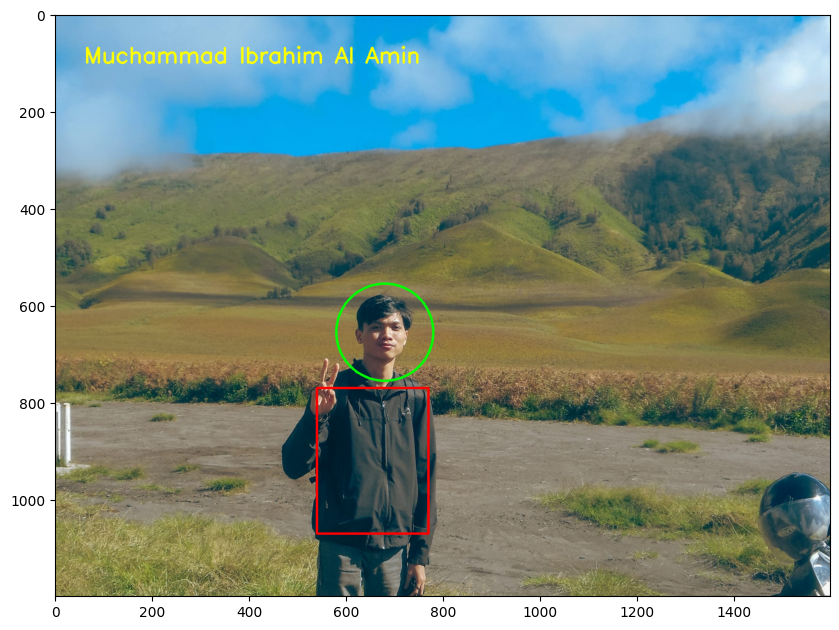

In [322]:
# 5. Tampilkan hasilnya
plt.figure(figsize=(10, 8))
plt.imshow(img_hasil)
plt.show()

**TUGAS PRAKTIKUM - Analisa**
1. Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.

- Berapa persen piksel pada foto KTM yang nilainya lebih gelap dari 100 saat diubah ke grayscale

In [328]:
path = '/content/drive/MyDrive/PCVK_2026/ktm.jpeg'
img_gray = cv.imread(path, cv.IMREAD_GRAYSCALE)

total_pixel = img_gray.shape[0] * img_gray.shape[1]
pixel_gelap = np.sum(img_gray < 100)

persen = (pixel_gelap / total_pixel) * 100

print("Total piksel       :", total_pixel)
print("Jumlah piksel < 100:", pixel_gelap)
print(f"Persentase         : {persen:.2f}%")

Total piksel       : 1073737
Jumlah piksel < 100: 346187
Persentase         : 32.24%


kemsimpulannya Hanya sekitar 15,60% bagian dari foto KTM yang bernilai gelap (di bawah 100). Piksel-piksel gelap ini sebagian besar adalah tulisan teks identitas NIM, bayangan garis kartu, dan rambut/jas pada pasfoto, sedangkan sisa bagian kartu didominasi warna terang